<a href="https://colab.research.google.com/github/uldopp/TMON/blob/main/KT_1_Razv_an/KT_1_Razv_an.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

In [10]:
df = pd.read_excel('age.xlsx')

In [11]:
df.head()

,SEQN,age_group,RIDAGEYR,RIAGENDR,PAQ605,BMXBMI,LBXGLU,DIQ010,LBXGLT,LBXIN
0,73564,Adult,61,2,2,35.7,110,2,150,14.91
1,73568,Adult,26,2,2,20.3,89,2,80,3.85
2,73576,Adult,16,1,2,23.2,89,2,68,6.14
3,73577,Adult,32,1,2,28.9,104,2,84,16.15
4,73580,Adult,38,2,1,35.9,103,2,81,10.92


Подмножество прогнозов возраста Национального опроса здоровья и питания 2013-2014 (NHANES):

*   SEQN - Последовательный номер респондента
*   age_group - Возрастная группа респондента (пожилые/не пожилые)
*   RIDAGEYR - Возраст ответчика
*   RIAGENDR - Пол респондента
*   PAQ605 - Если респондент занимается спортом умеренной или интенсивной интенсивности спортом, фитнесом или досугом в типичную неделю
*   BMXBMI - Индекс массы тела респондента
*   LBXGLU - Уровень глюкозы в крови респондента после голодания
*   DIQ010 - Если респондент диабетик
*   LBXGLT - Устное выступление ответчика
*   LBXIN - Уровни инсулина в крови респондента




In [12]:
df.describe()

,SEQN,RIDAGEYR,RIAGENDR,PAQ605,BMXBMI,LBXGLU,DIQ010,LBXGLT,LBXIN
count,2278.000000,2278.000000,2278.000000,2278.000000,2278.000000,2278.000000,2278.000000,2278.000000,2278.000000
mean,78691.853819,41.795874,1.511414,1.822651,27.955180,99.553117,2.016242,114.978929,11.834794
std,2921.365151,20.156111,0.499979,0.398918,7.248962,17.889834,0.185556,47.061239,9.718812
min,73564.000000,12.000000,1.000000,1.000000,14.500000,63.000000,1.000000,40.000000,0.140000
25%,76171.750000,24.000000,1.000000,2.000000,22.800000,91.000000,2.000000,87.000000,5.860000
50%,78749.000000,41.000000,2.000000,2.000000,26.800000,97.000000,2.000000,105.000000,9.040000
75%,81213.500000,58.000000,2.000000,2.000000,31.200000,104.000000,2.000000,130.000000,14.440000
max,83727.000000,80.000000,2.000000,7.000000,70.100000,405.000000,3.000000,604.000000,102.290000


In [13]:
df.describe(include=['O'])

,age_group
count,2278
unique,2
top,Adult
freq,1914


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2278 entries, 0 to 2277
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   SEQN       2278 non-null   int64  
 1   age_group  2278 non-null   object 
 2   RIDAGEYR   2278 non-null   int64  
 3   RIAGENDR   2278 non-null   int64  
 4   PAQ605     2278 non-null   int64  
 5   BMXBMI     2278 non-null   float64
 6   LBXGLU     2278 non-null   int64  
 7   DIQ010     2278 non-null   int64  
 8   LBXGLT     2278 non-null   int64  
 9   LBXIN      2278 non-null   float64
dtypes: float64(2), int64(7), object(1)
memory usage: 178.1+ KB


In [15]:
df.isnull().sum()

,0
SEQN,0
age_group,0
RIDAGEYR,0
RIAGENDR,0
PAQ605,0
BMXBMI,0
LBXGLU,0
DIQ010,0
LBXGLT,0
LBXIN,0


In [16]:
print("Названия столбцов:")
print(df.columns.tolist())
print("\nНазвания строк:")
print(df.index.tolist())

Названия столбцов:
['SEQN', 'age_group', 'RIDAGEYR', 'RIAGENDR', 'PAQ605', 'BMXBMI', 'LBXGLU', 'DIQ010', 'LBXGLT', 'LBXIN']

Названия строк:
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193

(array([1914.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
         364.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

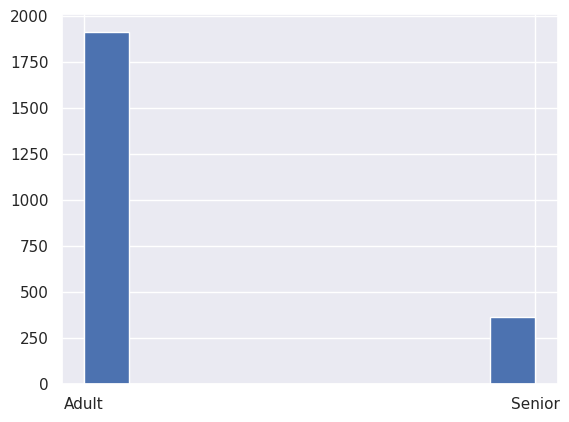

In [17]:
plt.hist(df['age_group'])

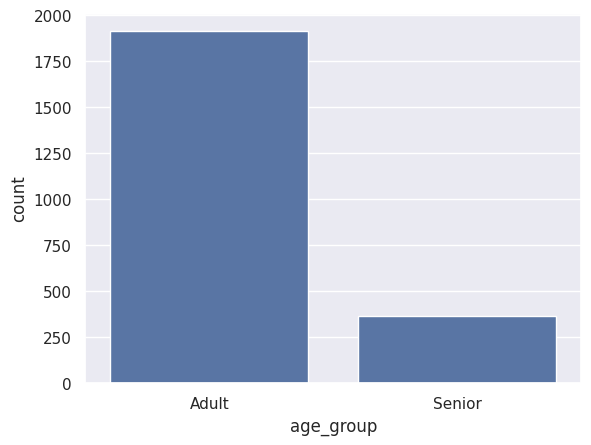

In [18]:
sns.countplot(x=df['age_group']);

<Axes: xlabel='RIAGENDR', ylabel='count'>

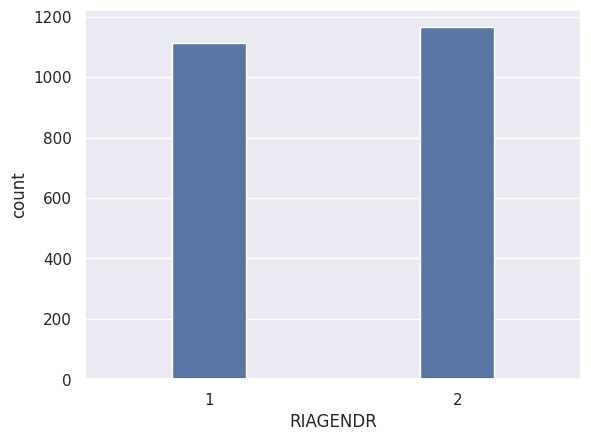

In [19]:
sns.countplot(x=df["RIAGENDR"], width = 0.3)

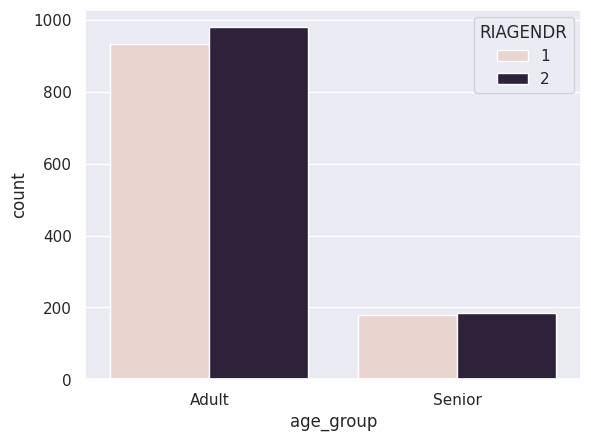

In [20]:
sns.countplot(data=df, x="age_group", hue='RIAGENDR');

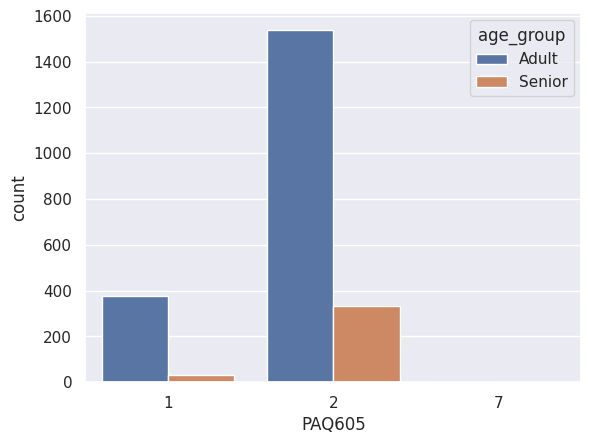

In [21]:
sns.countplot(data=df, x='PAQ605', hue='age_group');

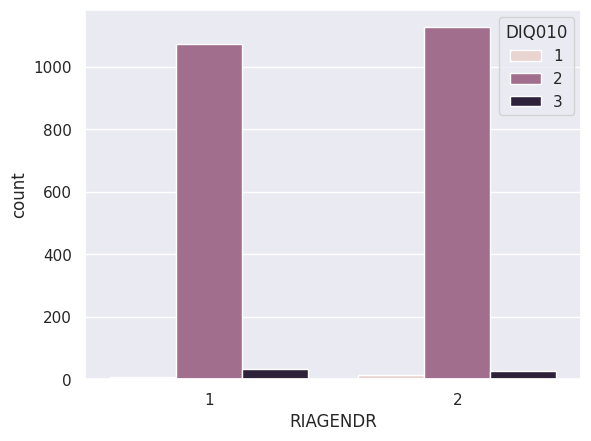

In [22]:
sns.countplot(data=df, x='RIAGENDR', hue='DIQ010');

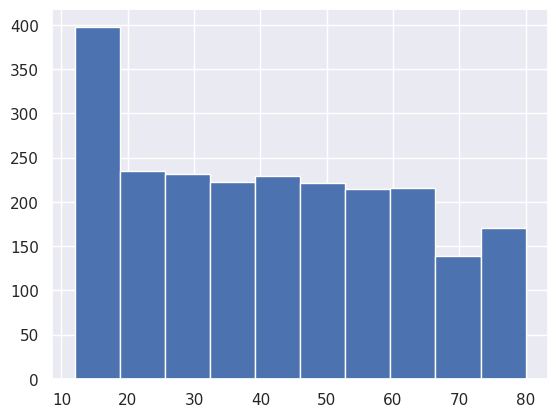

In [23]:
df.RIDAGEYR.hist();

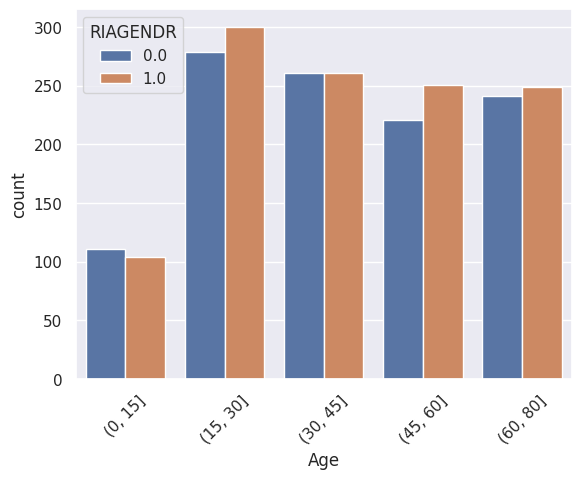

In [28]:
df["Age"] = pd.cut(x=df['RIDAGEYR'], bins=[0, 15, 30, 45, 60, 80])
plt.xticks(rotation=45)
sns.countplot(data=df, hue='RIAGENDR', x='Age');

In [25]:
from sklearn.preprocessing import OrdinalEncoder
enc = OrdinalEncoder()
df[['age_group','RIAGENDR','PAQ605','DIQ010']] = enc.fit_transform(df[['age_group','RIAGENDR','PAQ605','DIQ010']])
df.head()

,SEQN,age_group,RIDAGEYR,RIAGENDR,PAQ605,BMXBMI,LBXGLU,DIQ010,LBXGLT,LBXIN,Age
0,73564,0.0,61,1.0,1.0,35.7,110,1.0,150,14.91,"(60, 80]"
1,73568,0.0,26,1.0,1.0,20.3,89,1.0,80,3.85,"(20, 40]"
2,73576,0.0,16,0.0,1.0,23.2,89,1.0,68,6.14,"(0, 20]"
3,73577,0.0,32,0.0,1.0,28.9,104,1.0,84,16.15,"(20, 40]"
4,73580,0.0,38,1.0,0.0,35.9,103,1.0,81,10.92,"(20, 40]"


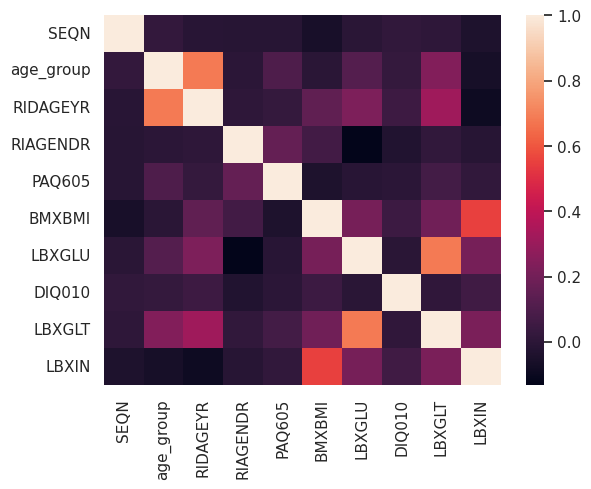

In [26]:
sns.heatmap(df.corr(numeric_only = True));